In [2]:
import os
from pathlib import Path

from dotenv import load_dotenv
import pandas as pd
import yaml

from src.tools.find_content import load_all_chunks_meta_fast
from src.tools.presets import get_list_of_presets
from src.tools.read.split_point.load_split_point import load_analyze_split_point_dataframes


load_dotenv()

ANALYZE_SPLIT_POINTS_DIR = Path(os.getenv("ANALYZE_SPLIT_POINTS_DIR"))
CHUNKS_DIR = Path(os.getenv("CHUNKS_DIR"))


with open("params_lit.yaml", "r", encoding="utf-8") as f:
    params = yaml.safe_load(f)

datasets_cfg = params.get("preprocess_datasets").get("datasets")
if not datasets_cfg:
    raise ValueError("Nie znaleziono datasets_download w params.yaml")

chunking_cfg = params.get("chunking").get("methods")
if not chunking_cfg:
    raise ValueError("Nie znaleziono chunking_methods w params.yaml")

analyze_cfg = params.get("analyze_retrieval").get("methods")
if not analyze_cfg:
    raise ValueError("Nie znaleziono analyze_retrieval_methods w params.yaml")

splits = params.get("chunking").get("splits")
if not splits:
    raise ValueError("Nie znaleziono splits w params.yaml")

dataset_names, dataset_params_names = get_list_of_presets(datasets_cfg)
chunking_names, chunking_params_names = get_list_of_presets(chunking_cfg)
analyze_split_point_names, analyze_split_point_names = get_list_of_presets(analyze_cfg)

configs = []
df_time = {}

for dataset, dataset_params in zip(dataset_names, dataset_params_names):
    for chunking, chunking_params in zip(chunking_names, chunking_params_names):
        for analyze, analyze_params in zip(analyze_split_point_names, analyze_split_point_names):
            for split in splits:
                configs.append({
                    "dataset_name": dataset,
                    "dataset_params_name": dataset_params,
                    "chunking_name": chunking,
                    "chunking_params_name": chunking_params,
                    "split_name": split
                })

                chunk_time_dict = load_all_chunks_meta_fast(
                    CHUNKS_DIR / dataset / dataset_params / chunking / chunking_params / split
                )

                idx = (
                    dataset,
                    dataset_params,
                    chunking,
                    chunking_params,
                    split,
                )
                df_time[idx] = chunk_time_dict.get("total_chunking_time")

df_time = pd.DataFrame.from_dict(
    df_time,
    orient="index",
    columns=["total_chunking_time"]
)

df_time.index = pd.MultiIndex.from_tuples(
    df_time.index,
    names=[
        "dataset_name",
        "dataset_params_name",
        "chunking_name",
        "chunking_params_name",
        "split_name",
    ]
)
split_point_df = load_analyze_split_point_dataframes(ANALYZE_SPLIT_POINTS_DIR, configs)


# kolumny z max_split_span -> NaN zamień na 0
max_split_cols = [col for col in split_point_df.columns if col.endswith("max_split_span")]
split_point_df[max_split_cols] = split_point_df[max_split_cols].fillna(0)

# 2. bazowa lista do dropa
cols_to_drop = [
    "sentence_correct",
    "sentence_incorrect",
    "sentence_total",
    "total_chunks",
    "total_boundaries",
    "bpr_start",
    "bpr_end",
    "boundary_violation_count",
    "orphaned_chunks",
    "orphaned_chunk_rate"
]

# 3. automatycznie dodaj tag_*_inside/splited/total
tag_suffixes = ("_inside", "_splited", "_total", "_avg_split_span", "_max_split_span")

tag_cols = [
    col for col in split_point_df.columns
    if col.endswith(tag_suffixes)
]

cols_to_drop.extend(tag_cols)

# 4. drop (bez błędu jeśli coś nie istnieje)
split_point_df = split_point_df.drop(columns=cols_to_drop)
split_point_df = split_point_df.join(df_time)
# opcjonalnie sprawdzenie
split_point_df

h1_block_integrity_rate  \
dataset_name dataset_params_name chunking_name      chunking_params_name split_name                            
literaryQA   default             chonkie_semantic   norm                 test                            1.0   
                                 fixed_size         norm_token           test                            1.0   
                                 lumber             default_vllm         test                            1.0   
                                 max_min            norm                 test                            1.0   
                                 neural             default              test                            1.0   
                                 recursive          norm                 test                            1.0   
                                 recursive_semantic norm                 test                            1.0   
                                 sequential_hac     norm                 test                            1.0   

                                                                                     h2_block_integrity_rate  \
dataset_name dataset_params_name chunking_name      chunking_params_name split_name                            
literaryQA   default             chonkie_semantic   norm                 test                       0.980806   
                                 fixed_size         norm_token           test                       0.854894   
                                 lumber             default_vllm         test                       0.949328   
                                 max_min            norm                 test                       0.957774   
                                 neural             default              test                       0.975048   
                                 recursive          norm                 test                       0.999616   
                                 recursive_semantic norm                 test                       0.996161   
                                 sequential_hac     norm                 test                       0.974280   

                                                                                     h3_block_integrity_rate  \
dataset_name dataset_params_name chunking_name      chunking_params_name split_name                            
literaryQA   default             chonkie_semantic   norm                 test                       0.996711   
                                 fixed_size         norm_token           test                       0.840789   
                                 lumber             default_vllm         test                       0.998684   
                                 max_min            norm                 test                       0.989474   
                                 neural             default              test                       0.996053   
                                 recursive          norm                 test                       1.000000   
                                 recursive_semantic norm                 test                       0.997368   
                                 sequential_hac     norm                 test                       0.999342   

                                                                                     h4_block_integrity_rate  \
dataset_name dataset_params_name chunking_name      chunking_params_name split_name                            
literaryQA   default             chonkie_semantic   norm                 test                       0.992105   
                                 fixed_size         norm_token           test                       0.876316   
                                 lumber             default_vllm         test                       1.000000   
                                 max_min            norm                 test                       0.989474   
                                 neural           

In [13]:
s1

dataset_name         dataset_params_name  chunking_name       chunking_params_name  split_name
novelQA              default              fixed_size          norm_token            all              12.659609
                                          recursive           norm                  all               1.094413
                                          recursive_semantic  norm                  all            6304.828292
                                          neural              default               all            2755.035602
                                          chonkie_semantic    norm                  all             203.710619
                                          lumber              default_vllm          all           18700.885944
                                          max_min             norm                  all            1174.938243
                                          sequential_hac      norm                  all            1080.070875
infiniteBenchQA  

In [3]:
split_point_df['total_chunking_time']

dataset_name  dataset_params_name  chunking_name       chunking_params_name  split_name
literaryQA    default              chonkie_semantic    norm                  test           220.453572
                                   fixed_size          norm_token            test            14.905953
                                   lumber              default_vllm          test          9843.015086
                                   max_min             norm                  test           878.892321
                                   neural              default               test          1760.156341
                                   recursive           norm                  test             1.124257
                                   recursive_semantic  norm                  test          4771.766018
                                   sequential_hac      norm                  test           751.962919
Name: total_chunking_time, dtype: float64

In [14]:
import pandas as pd

# jeśli split_point_df['total_chunking_time'] jest Series:
s1 = s1
s2 = split_point_df['total_chunking_time']

# połączenie (dopasowanie po indeksie)
result = pd.concat([s1, s2]).to_frame(name='total_chunking_time')

# zapis do CSV
result.to_csv("a.csv")

In [15]:
import pandas as pd
import numpy as np

# =========================
# 1. Wczytanie danych
# =========================
df = pd.read_csv("a.csv")

# =========================
# 2. Pivot: dataset_name x chunking_name
# =========================
table = df.pivot_table(
    index="dataset_name",
    columns="chunking_name",
    values="total_chunking_time",
    aggfunc="mean"
)

# =========================
# 3. Formatowanie czasu (s / min / h)
# =========================
def format_time(seconds):
    if pd.isna(seconds):
        return ""

    if seconds < 60:
        return f"{seconds:.2f} s"
    elif seconds < 3600:
        return f"{seconds / 60:.2f} min"
    else:
        return f"{seconds / 3600:.2f} h"

table_fmt = table.applymap(format_time)

# =========================
# 4. AVG dla każdego chunking_name
# =========================
avg_row = table.mean(axis=0)
avg_row_fmt = avg_row.apply(format_time)
avg_row_fmt.name = "AVG"

table_fmt = pd.concat([table_fmt, avg_row_fmt.to_frame().T])

# =========================
# 5. Export do LaTeX
# =========================
latex = table_fmt.to_latex(
    escape=False,
    na_rep="",
    index=True,
    column_format="l" + "c" * table_fmt.shape[1]
)

with open("table.tex", "w") as f:
    f.write(latex)

print("Zapisano table.tex")

Zapisano table.tex


/tmp/ipykernel_149856/1988673549.py:33: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  table_fmt = table.applymap(format_time)


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import math


def plot_metrics_subplots(df, metric_cols, ncols=2):

    labels = [
        " | ".join(map(str, idx))
        for idx in df.index
    ]

    n_metrics = len(metric_cols)
    nrows = math.ceil(n_metrics / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6 * ncols, 4 * nrows),
        constrained_layout=True
    )

    axes = np.array(axes).reshape(-1)

    colors = plt.cm.tab20(np.linspace(0, 1, len(df)))

    # 🔥 stabilna legenda (nie zależy od barów)
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=color)
        for color in colors
    ]

    for ax, metric in zip(axes, metric_cols):

        values = df[metric].values

        for i, val in enumerate(values):
            ax.bar(i, val, color=colors[i])

            # wartości nad słupkami
            ax.text(
                i,
                val,
                f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

        ax.set_title(metric)
        ax.set_xticks([])

        # 🔥 specjalna skala dla czasu
        if metric == "total_chunking_time":
            max_val = np.max(values)
            ax.set_ylim(0, max_val * 1.2 if max_val > 0 else 1)
        else:
            ax.set_ylim(0, 1)

    # usuń puste subplots
    for ax in axes[n_metrics:]:
        fig.delaxes(ax)

    # 🔥 legenda globalna
    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )

    return fig, axes

In [5]:
split_point_df.columns

Index(['h1_block_integrity_rate', 'h2_block_integrity_rate',
       'h3_block_integrity_rate', 'h4_block_integrity_rate',
       'h5_block_integrity_rate', 'h6_block_integrity_rate',
       'p_block_integrity_rate', 'pre_block_integrity_rate',
       'block_integrity_rate', 'boundary_violation_rate',
       'sentence_correct_rate', 'total_chunking_time'],
      dtype='object')

In [9]:
for i in range(len(split_point_df)):
    print(f"\nIndex: {split_point_df.index[i][2]}")

    for metric in metric_cols:
        print(f"{metric}: {split_point_df[metric].iloc[i]}")


Index: chonkie_semantic
block_integrity_rate: 0.8456946016338917
boundary_violation_rate: 0.6650505866707068
sentence_correct_rate: 0.9753211117283639

Index: fixed_size
block_integrity_rate: 0.608780314225137
boundary_violation_rate: 0.9684713139120095
sentence_correct_rate: 0.010199910820451843

Index: lumber
block_integrity_rate: 0.8624387784856108
boundary_violation_rate: 0.5437727474478473
sentence_correct_rate: 0.9826719928983577

Index: max_min
block_integrity_rate: 0.8581884856602039
boundary_violation_rate: 0.6223634837139969
sentence_correct_rate: 0.9693298836591676

Index: neural
block_integrity_rate: 0.9901106558794893
boundary_violation_rate: 0.17100681302043907
sentence_correct_rate: 0.7537471612414838

Index: recursive
block_integrity_rate: 0.975506452043353
boundary_violation_rate: 0.1044720890893713
sentence_correct_rate: 0.9679130250916267

Index: recursive_semantic
block_integrity_rate: 0.9288619593849925
boundary_violation_rate: 0.28438841201716736
sentence_correct

(<Figure size 1800x1600 with 11 Axes>,
 array([<Axes: title={'center': 'h1_block_integrity_rate'}>,
        <Axes: title={'center': 'h2_block_integrity_rate'}>,
        <Axes: title={'center': 'h3_block_integrity_rate'}>,
        <Axes: title={'center': 'h4_block_integrity_rate'}>,
        <Axes: title={'center': 'h5_block_integrity_rate'}>,
        <Axes: title={'center': 'h6_block_integrity_rate'}>,
        <Axes: title={'center': 'p_block_integrity_rate'}>,
        <Axes: title={'center': 'pre_block_integrity_rate'}>,
        <Axes: title={'center': 'block_integrity_rate'}>,
        <Axes: title={'center': 'boundary_violation_rate'}>,
        <Axes: title={'center': 'sentence_correct_rate'}>, <Axes: >],
       dtype=object))

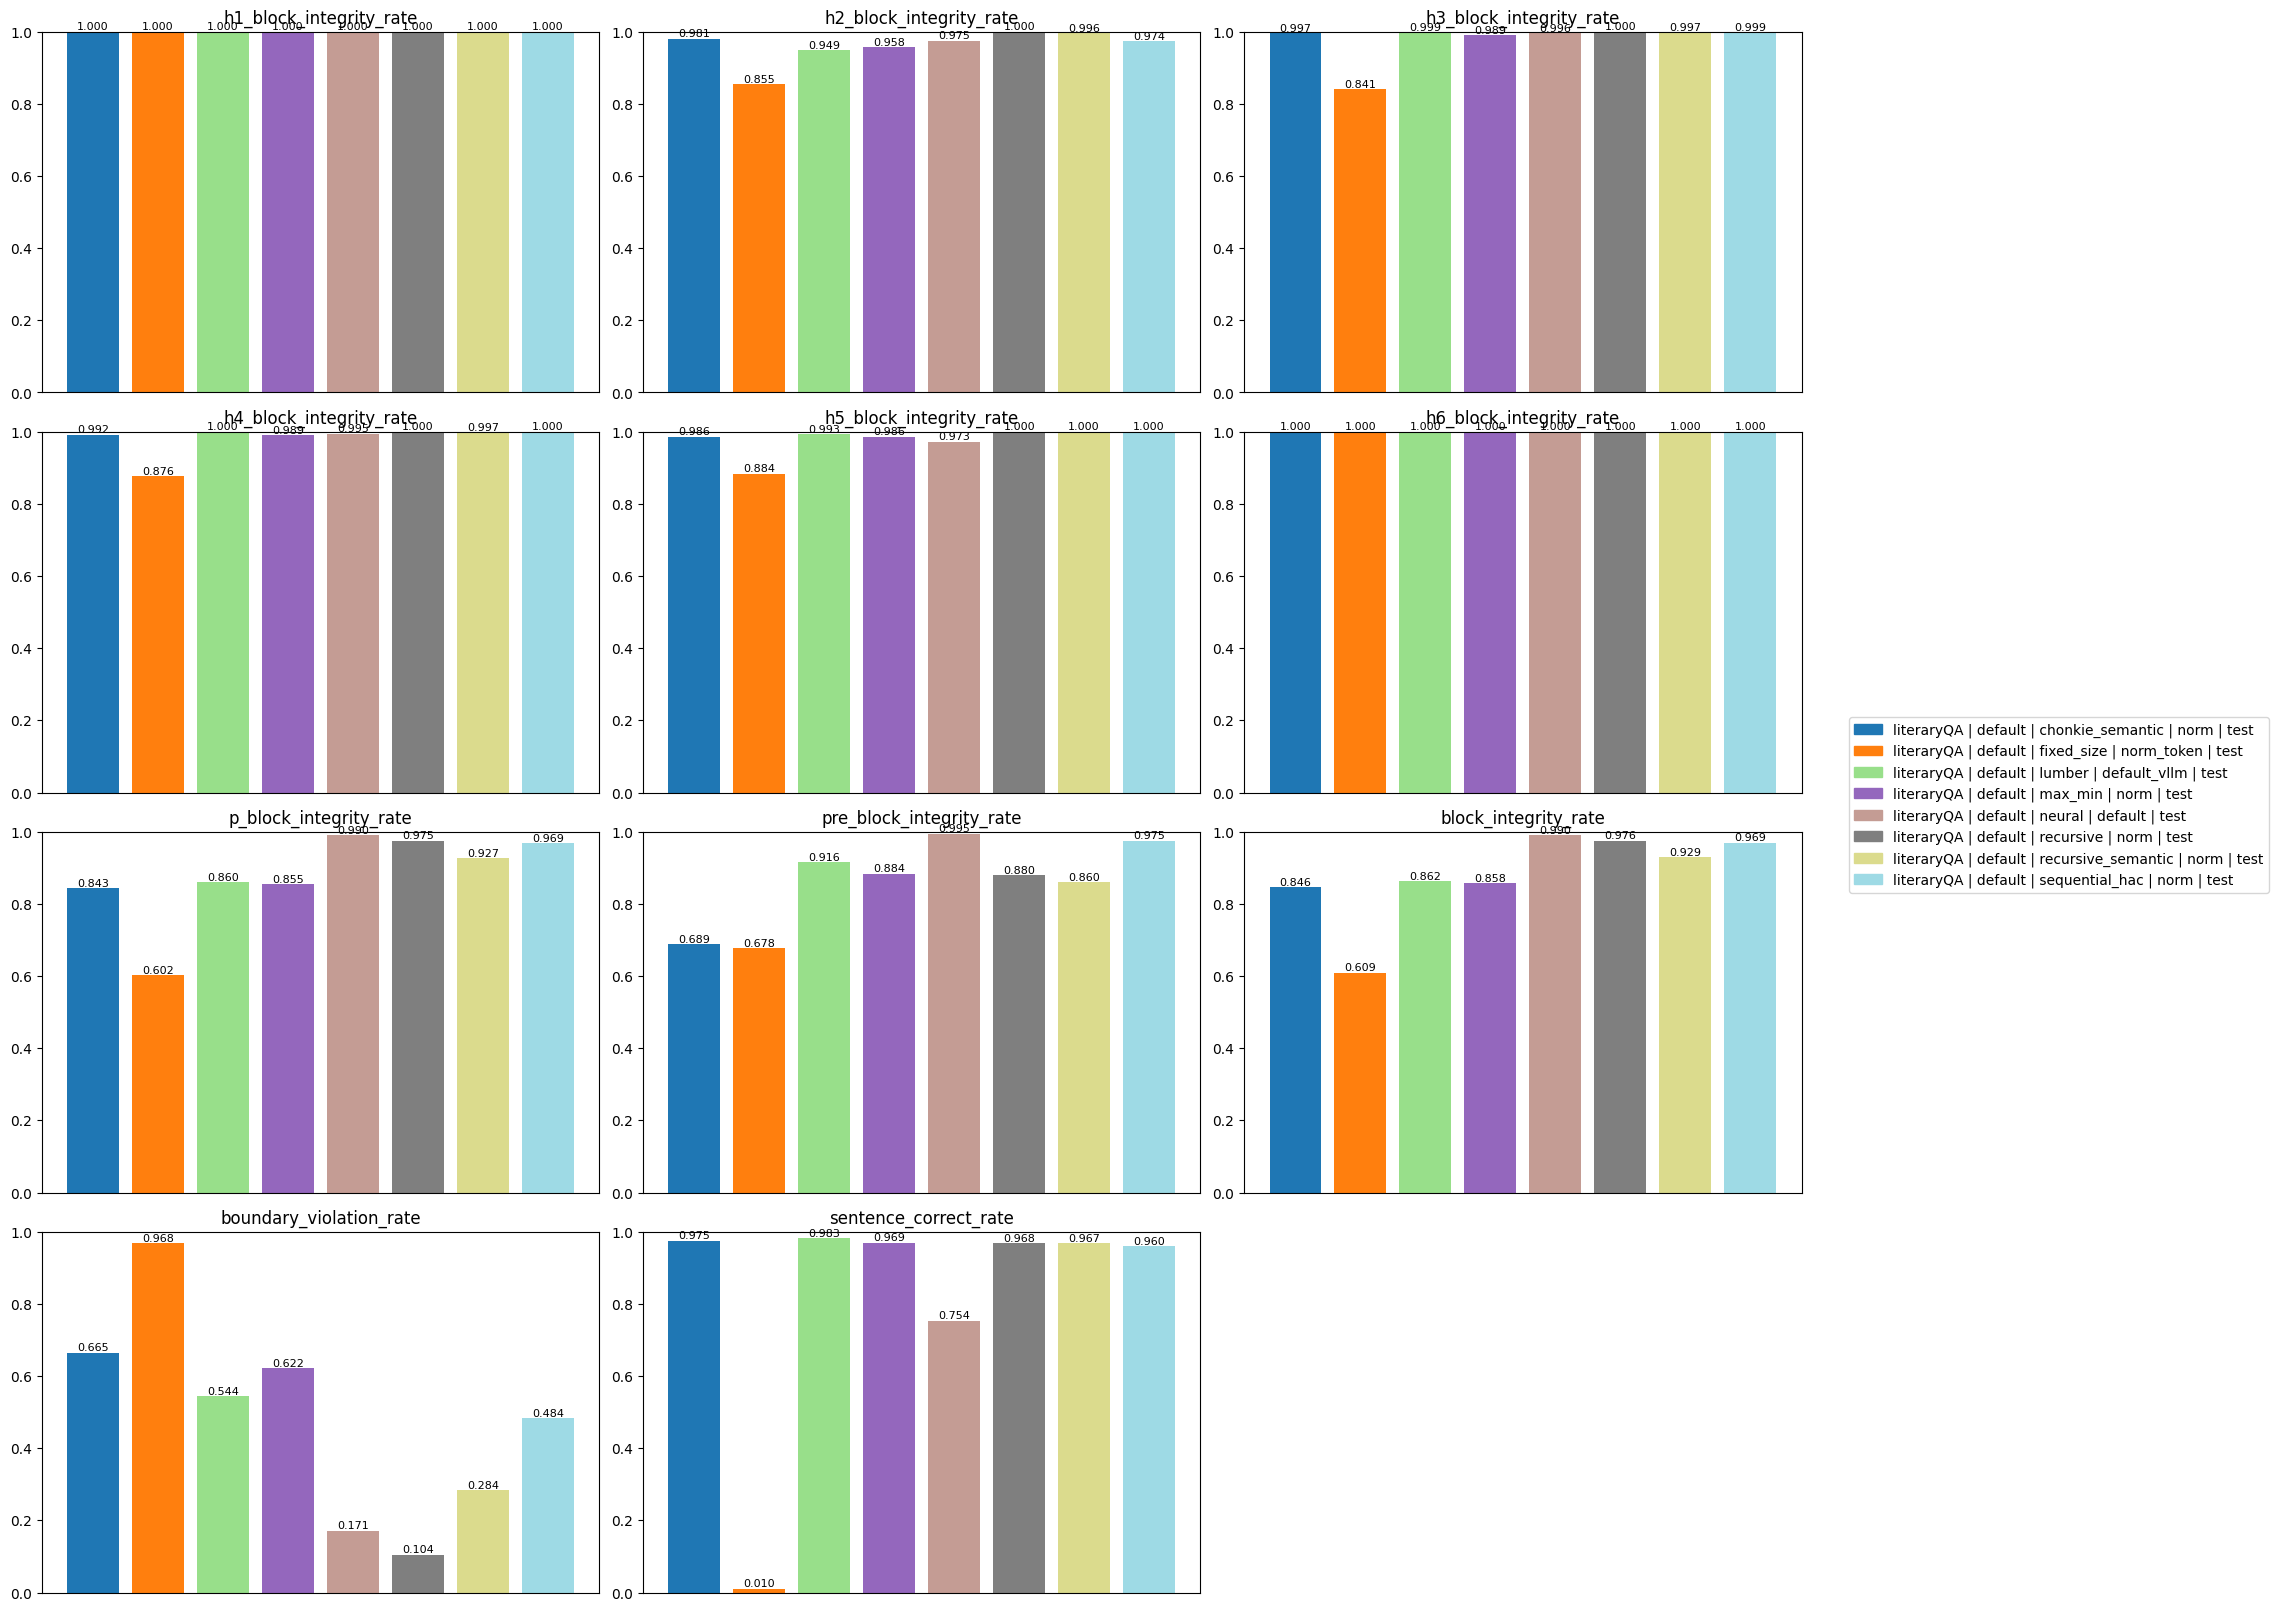

In [10]:
metric_cols = [
    "h1_block_integrity_rate",
    "h2_block_integrity_rate",
    "h3_block_integrity_rate",
    "h4_block_integrity_rate",
    "h5_block_integrity_rate",
    "h6_block_integrity_rate",
    "p_block_integrity_rate",
    "pre_block_integrity_rate",
    "block_integrity_rate",
    "boundary_violation_rate",
    "sentence_correct_rate"
]
plot_metrics_subplots(split_point_df, metric_cols, 3)

In [5]:
from matplotlib import pyplot as plt


def plot_time(df, time_column_name):
    labels = [
        " | ".join(map(str, idx))
        for idx in df.index
    ]

    fig, ax = plt.subplots(figsize=(14, 5))

    x = range(len(df))

    ax.bar(x, df[time_column_name])

    ax.set_title(time_column_name)
    ax.set_ylabel("time [s]")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90)

    return fig, ax

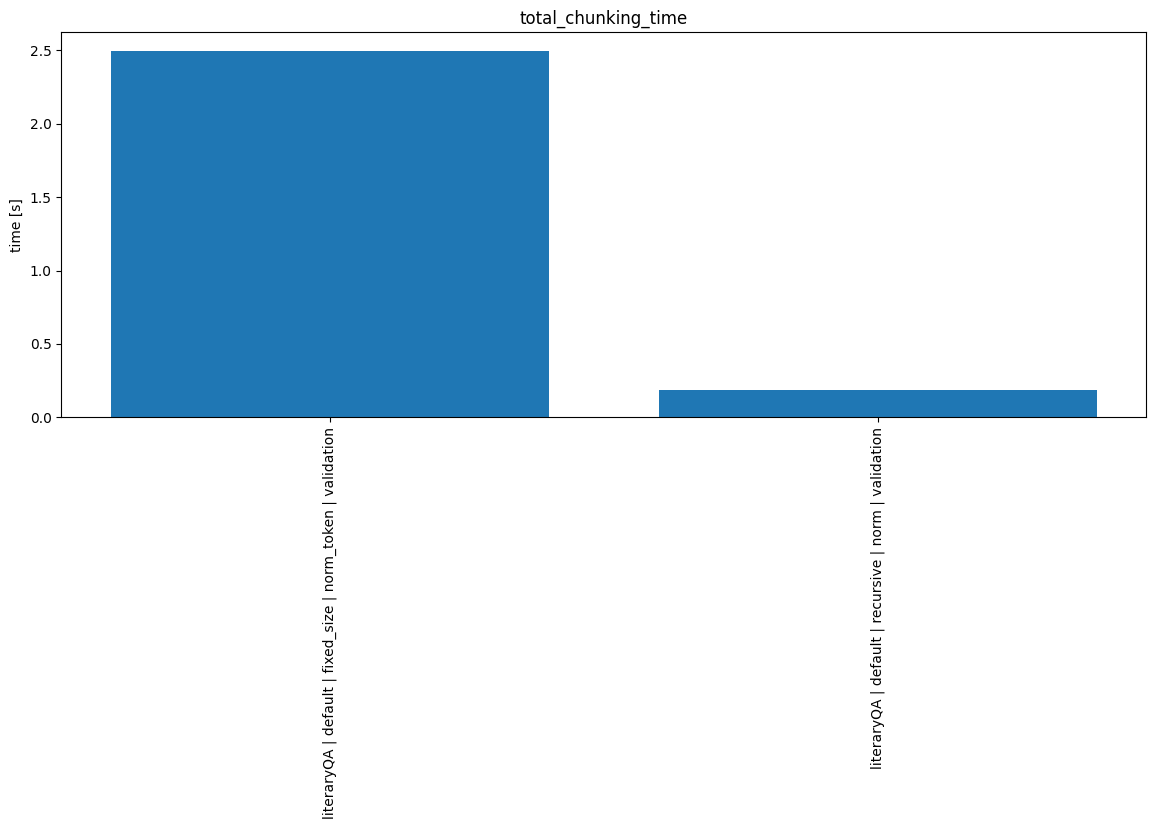

In [26]:
fig, ax = plot_time(split_point_df, 'total_chunking_time')
plt.show()